In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [2]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(df.shape)
df.head()

Saving customer_churn_random_forest.csv to customer_churn_random_forest.csv
(1000, 14)


,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,InternetService,Contract,PaymentMethod,PaperlessBilling,tenure,MonthlyCharges,TotalCharges,Churn
0,CUST10001,Male,0,No,No,Yes,Fiber optic,Month-to-month,Electronic check,Yes,51,85.39,3759.39,No
1,CUST10002,Female,0,Yes,No,Yes,Fiber optic,Month-to-month,Electronic check,No,54,112.26,5521.01,No
2,CUST10003,Male,0,Yes,No,No,DSL,Month-to-month,Mailed check,Yes,59,25.67,1588.54,No
3,CUST10004,Male,0,Yes,No,Yes,DSL,Month-to-month,Electronic check,Yes,6,22.95,118.75,No
4,CUST10005,Male,0,Yes,Yes,Yes,Fiber optic,Month-to-month,Electronic check,Yes,29,37.83,1167.03,No


In [3]:
list(uploaded.keys())

['customer_churn_random_forest.csv']

In [4]:

import pandas as pd

df = pd.read_csv('/content/customer_churn_random_forest.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,InternetService,Contract,PaymentMethod,PaperlessBilling,tenure,MonthlyCharges,TotalCharges,Churn
0,CUST10001,Male,0,No,No,Yes,Fiber optic,Month-to-month,Electronic check,Yes,51,85.39,3759.39,No
1,CUST10002,Female,0,Yes,No,Yes,Fiber optic,Month-to-month,Electronic check,No,54,112.26,5521.01,No
2,CUST10003,Male,0,Yes,No,No,DSL,Month-to-month,Mailed check,Yes,59,25.67,1588.54,No
3,CUST10004,Male,0,Yes,No,Yes,DSL,Month-to-month,Electronic check,Yes,6,22.95,118.75,No
4,CUST10005,Male,0,Yes,Yes,Yes,Fiber optic,Month-to-month,Electronic check,Yes,29,37.83,1167.03,No


In [5]:
print(df.shape)
print(df.columns)

(1000, 14)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'InternetService', 'Contract', 'PaymentMethod',
       'PaperlessBilling', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   object 
 1   gender            1000 non-null   object 
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   object 
 4   Dependents        1000 non-null   object 
 5   PhoneService      1000 non-null   object 
 6   InternetService   1000 non-null   object 
 7   Contract          1000 non-null   object 
 8   PaymentMethod     1000 non-null   object 
 9   PaperlessBilling  1000 non-null   object 
 10  tenure            1000 non-null   int64  
 11  MonthlyCharges    1000 non-null   float64
 12  TotalCharges      990 non-null    float64
 13  Churn             1000 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 109.5+ KB


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'InternetService', 'Contract', 'PaymentMethod',
       'PaperlessBilling', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.000000,990.000000
mean,0.168000,35.945000,70.042580,2472.258899
std,0.374053,20.753185,28.943294,1886.446148
min,0.000000,1.000000,20.020000,30.490000
25%,0.000000,18.000000,46.135000,929.175000
50%,0.000000,36.000000,69.655000,2028.710000
75%,0.000000,53.000000,94.180000,3624.265000
max,1.000000,72.000000,119.950000,8884.420000


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
PhoneService,0
InternetService,0
Contract,0
PaymentMethod,0
PaperlessBilling,0


In [14]:
df.duplicated().sum()

np.int64(0)

**Understand** the Target Variable

In [16]:
df["Churn"].value_counts()

,count
Churn,
No,890
Yes,110


In [17]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,89.0
Yes,11.0


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

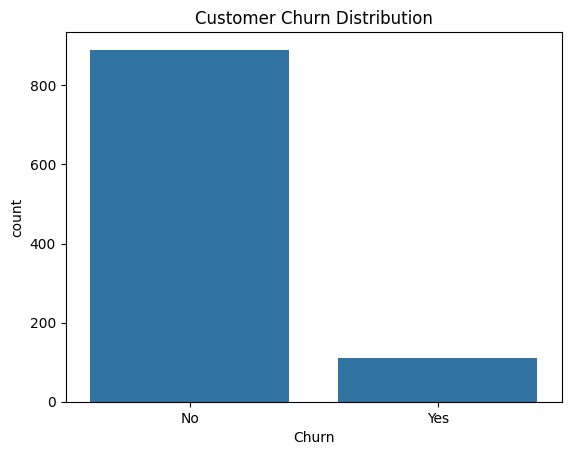

In [21]:
# Visualize
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

This tells us that the dataset is imbalanced.

**Data Cleaning**
A common issue in the Telco Churn dataset is that TotalCharges may contain blank values.

Convert it to numeric:

Convert it to numeric:

In [22]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [23]:
# Check missing values
df["TotalCharges"].isnull().sum()

np.int64(10)

In [9]:
# Fill missing values:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

6. Remove Unnecessary Columns

customerID is an identifier and doesn't provide useful predictive information.

In [10]:
df = df.drop("customerID", axis=1)

7. Convert Categorical **Variables**

Machine-learning algorithms require numerical representations of categorical data.

First identify categorical columns:

In [11]:
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService',
       'Contract', 'PaymentMethod', 'PaperlessBilling', 'Churn'],
      dtype='object')

One-Hot Encoding.


In [12]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [13]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaperlessBilling_Yes,Churn_Yes
0,0,51,85.39,3759.39,True,False,False,True,True,False,False,False,False,True,False,True,False
1,0,54,112.26,5521.01,False,True,False,True,True,False,False,False,False,True,False,False,False
2,0,59,25.67,1588.54,True,True,False,False,False,False,False,False,False,False,True,True,False
3,0,6,22.95,118.75,True,True,False,True,False,False,False,False,False,True,False,True,False
4,0,29,37.83,1167.03,True,True,True,True,True,False,False,False,False,True,False,True,False


Instead of:

Contract = Month-to-month

we may have columns such as:

Contract_One year

Contract_Two year

8. Separate Features and **Target**

In [14]:

X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

9. Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

stratify=y?

Because our target is imbalanced. It helps maintain a similar proportion of:

Churn = Yes

Churn = No

in both training and testing datasets.

10. Create Random Forest Model

In [20]:
from sklearn.ensemble import RandomForestClassifier


In [22]:
model = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

Train the Model

In [23]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

During training, Random Forest:

Step 1: Creates different bootstrap samples.

Step 2: Builds a Decision Tree for each sample.

Step 3: At each split, considers a random subset of features.

Step 4: Repeats this process for many trees.

Step 5: Combines all tree predictions.

12. Make Predictions

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

13. Calculate Accuracy

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.885


14. Classification Report

In [32]:
from sklearn.metrics import classification_report

In [33]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

       False       0.89      0.99      0.94       178
        True       0.33      0.05      0.08        22

    accuracy                           0.89       200
   macro avg       0.61      0.52      0.51       200
weighted avg       0.83      0.89      0.84       200



15. Confusion Matrix

In [35]:
from sklearn.metrics import confusion_matrix

In [36]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[176   2]
 [ 21   1]]


In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

In [44]:
import matplotlib.pyplot as plt

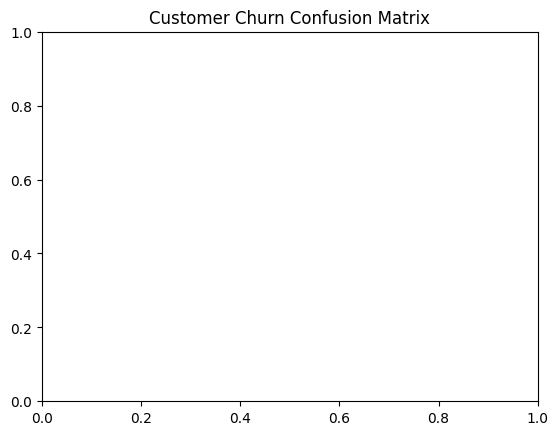

In [45]:
plt.title("Customer Churn Confusion Matrix")
plt.show()

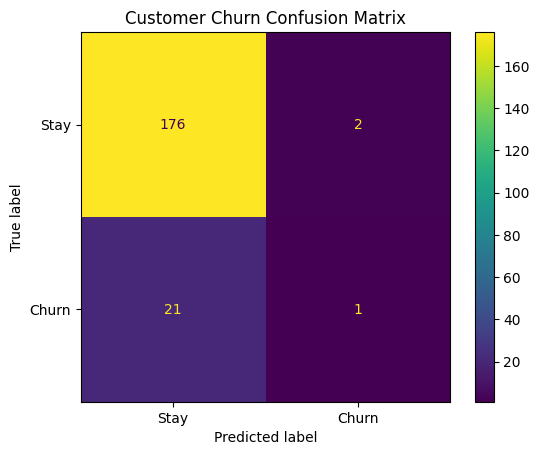

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
)

disp.plot()

plt.title("Customer Churn Confusion Matrix")
plt.show()

16. Probability Prediction
Random Forest can also give probabilities.

In [49]:
y_probability = model.predict_proba(X_test)

In [50]:
y_probability = model.predict_proba(X_test)[:, 1]

In [51]:
y_probability[:5]

array([0.2, 0.4, 0.2, 0. , 0. ])

In [53]:
churn_probability = model.predict_proba(X_test)[:, 1]


17. ROC-**AUC**

In [54]:
auc = roc_auc_score(
    y_test,
    churn_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.6201481103166496


ROC-AUC measures how well the model distinguishes between the two classes across classification thresholds.

**What is ROC?**
ROC = Receiver Operating Characteristic

**What is AUC?**
AUC = Area Under the Curve

It gives us a single number representing the model's ability to distinguish between the two classes.

18. Feature **Importance** **bold text**

In [55]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

In [56]:
# Display top 10:
importance.head(10)

,0
tenure,0.234256
TotalCharges,0.224187
MonthlyCharges,0.197112
Partner_Yes,0.045938
SeniorCitizen,0.032300
PaymentMethod_Electronic check,0.031938
PaperlessBilling_Yes,0.029573
Dependents_Yes,0.029508
PaymentMethod_Credit card,0.028497
Contract_One year,0.028293


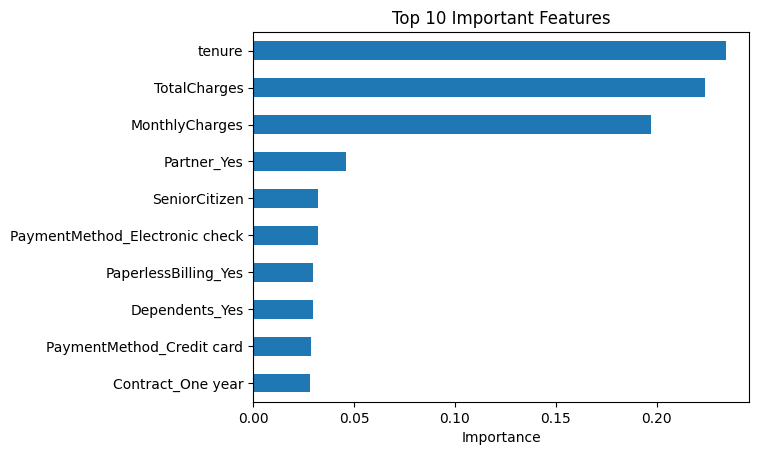

In [57]:
#Visulization
importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()